In [ ]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------
# Physical constants & setup
# ------------------------------------------------------------
N = 5                             # number of dipoles
G = 1.0                           # coupling constant (arbitrary units)
dtype = torch.float64

# Random initial positions and dipole moments
pos = torch.randn(N, 3, dtype=dtype, requires_grad=True)
dip = torch.randn(N, 3, dtype=dtype, requires_grad=True)


# ------------------------------------------------------------
# Dipole–dipole interaction energy
# ------------------------------------------------------------
def dipole_energy(positions, dipoles):
    # positions: (N,3)
    # dipoles: (N,3)
    diff = positions[:, None, :] - positions[None, :, :]   # (N,N,3)
    r = torch.linalg.norm(diff, dim=-1)                    # (N,N)
    r3 = r**3
    r5 = r**5

    # Avoid self-interaction singularities
    mask = torch.eye(len(positions), dtype=torch.bool)
    r3[mask] = float('inf')
    r5[mask] = float('inf')

    # dot products
    mu_i_dot_mu_j = dipoles @ dipoles.T
    mu_i_dot_r = (dipoles.unsqueeze(1) * diff).sum(dim=-1)
    mu_j_dot_r = (dipoles.unsqueeze(0) * diff).sum(dim=-1)

    # dipole potential
    V = (
        mu_i_dot_mu_j / r3
        - 3 * (mu_i_dot_r * mu_j_dot_r) / r5
    )

    # Only count i<j terms
    V_total = torch.sum(torch.triu(V, diagonal=1))

    return G * V_total


# ------------------------------------------------------------
# Gradient check
# ------------------------------------------------------------
E = dipole_energy(pos, dip)
E.backward()

print("Energy:", E.item())
print("Gradient on positions:\n", pos.grad)
print("Gradient on dipoles:\n", dip.grad)


# ------------------------------------------------------------
# Simple time–stepping simulation (gradient descent style)
# ------------------------------------------------------------
positions = pos.clone().detach().requires_grad_(True)

dipoles = dip.clone().detach().requires_grad_(True)
optimizer = torch.optim.Adam([positions, dipoles], lr=0.01)

all_positions = []

for step in range(200):
    optimizer.zero_grad()
    energy = dipole_energy(positions, dipoles)
    energy.backward()
    optimizer.step()

    with torch.no_grad():
        dipoles /= torch.linalg.norm(dipoles, dim=-1, keepdim=True)

    all_positions.append(positions.detach().clone())

# print("\nRelaxed positions:\n", positions.detach())
# print("Relaxed dipoles:\n", dipoles.detach())

# ---------------

Energy: -0.9943226369677131
Gradient on positions:
 tensor([[-1.4085,  1.0249,  0.7167],
        [ 2.9699, -0.5215, -1.4170],
        [-0.9788,  0.0406,  0.7991],
        [-1.0597, -0.5404, -0.7884],
        [ 0.4770, -0.0035,  0.6896]], dtype=torch.float64)
Gradient on dipoles:
 tensor([[-0.5019,  0.2896,  0.1534],
        [-0.6865, -0.0725,  0.9299],
        [-1.1521, -1.7191,  0.5079],
        [-0.4416, -1.3488, -1.1337],
        [ 0.1408, -0.0293,  0.0593]], dtype=torch.float64)


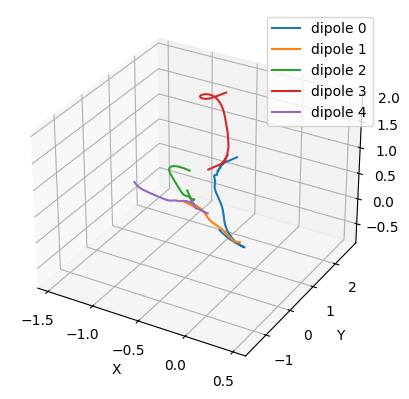

In [ ]:

#plot the change of positions 
# Could also be animation
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for i in range(5):
    x = [pos[i][0].item() for pos in all_positions]
    y = [pos[i][1].item() for pos in all_positions]
    z = [pos[i][2].item() for pos in all_positions]
    ax.plot(x, y, z, label=f'dipole {i}')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()